In [1]:
import sklearn
print(sklearn.__version__)

1.2.2


In [2]:
#list of useful libraries required for the project
import os
import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2
from glob import glob
import seaborn as sns
import random
import tensorflow as tf

#from keras.utils.np_utils import to_categorical#convert to one-hot-encoding
from keras.models import Sequential
from keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPool2D,GlobalAvgPool2D,GlobalMaxPooling2D
from keras.optimizers import RMSprop

from keras.optimizers import Adam
from sklearn.model_selection import train_test_split  


In [3]:
#pip install tensorflow

In [4]:
data=r'C:\Users\asus\Music\AMBULANCE\DATASET'

In [5]:
Images=[]
import os
for dirname,_,filenames in os.walk(data):
    for filename in filenames:
        img=os.path.join(dirname,filename)
        Images.append(img)

In [6]:
Images[:10]

['C:\\Users\\asus\\Music\\AMBULANCE\\DATASET\\ambulance\\1.jpg',
 'C:\\Users\\asus\\Music\\AMBULANCE\\DATASET\\ambulance\\10.jpg',
 'C:\\Users\\asus\\Music\\AMBULANCE\\DATASET\\ambulance\\11.jpg',
 'C:\\Users\\asus\\Music\\AMBULANCE\\DATASET\\ambulance\\12.jpg',
 'C:\\Users\\asus\\Music\\AMBULANCE\\DATASET\\ambulance\\13.jpg',
 'C:\\Users\\asus\\Music\\AMBULANCE\\DATASET\\ambulance\\14.jpg',
 'C:\\Users\\asus\\Music\\AMBULANCE\\DATASET\\ambulance\\15.jpg',
 'C:\\Users\\asus\\Music\\AMBULANCE\\DATASET\\ambulance\\16.jpg',
 'C:\\Users\\asus\\Music\\AMBULANCE\\DATASET\\ambulance\\17.jpg',
 'C:\\Users\\asus\\Music\\AMBULANCE\\DATASET\\ambulance\\18.jpg']

In [7]:
len(Images)

51

In [8]:
class_label=[]
for i in Images:
    j=i.split('\\')
    class_label.append(j[-2])

In [9]:
class_label[:10]

['ambulance',
 'ambulance',
 'ambulance',
 'ambulance',
 'ambulance',
 'ambulance',
 'ambulance',
 'ambulance',
 'ambulance',
 'ambulance']

In [10]:
len(class_label)

51

In [11]:
#shuffle two lists with same order
temp=list(zip(Images,class_label))
random.shuffle(temp)
Images,class_label=zip(*temp)
data=pd.DataFrame(list(zip(Images,class_label)),columns=['image_path','class_label'])

In [12]:
data.shape

(51, 2)

In [13]:
data.class_label.value_counts()

class_label
ambulance    30
traffic      21
Name: count, dtype: int64

In [14]:
from sklearn.utils import resample
df_c0 = data[data['class_label']== 'ambulance']
df_c1 = data[data['class_label']== 'traffic']


In [15]:
#downsample the majority class
upsampled_df_c0=resample(df_c0,replace=True,random_state=23,n_samples=5000)
upsampled_df_c1=resample(df_c1,replace=True,random_state=23,n_samples=5000)

In [16]:
#Cobine both
df_upsampled=pd.concat([upsampled_df_c0,upsampled_df_c1])

In [17]:
df_upsampled.head()

,image_path,class_label
33,C:\Users\asus\Music\AMBULANCE\DATASET\ambulanc...,ambulance
12,C:\Users\asus\Music\AMBULANCE\DATASET\ambulanc...,ambulance
14,C:\Users\asus\Music\AMBULANCE\DATASET\ambulanc...,ambulance
18,C:\Users\asus\Music\AMBULANCE\DATASET\ambulanc...,ambulance
37,C:\Users\asus\Music\AMBULANCE\DATASET\ambulanc...,ambulance


In [18]:
df_upsampled.class_label.value_counts()

class_label
ambulance    5000
traffic      5000
Name: count, dtype: int64

In [19]:
data = df_upsampled.sample(frac=1)
data.shape

(10000, 2)

Text(0.5, 0, 'Class_label')

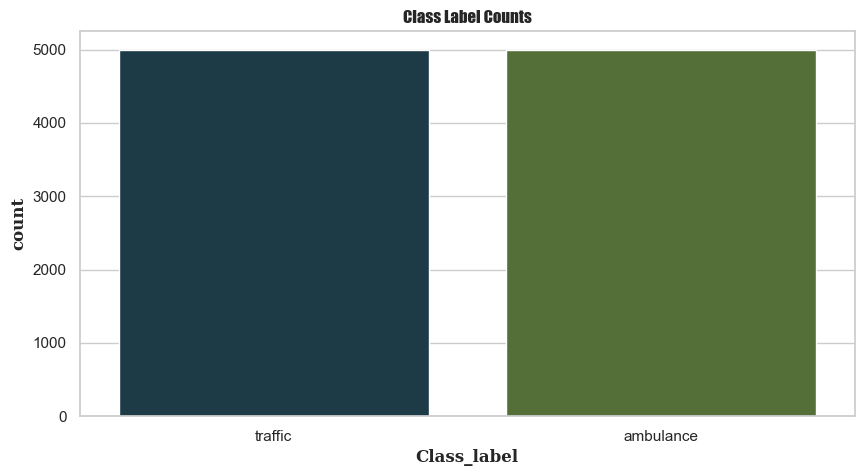

In [20]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 5))
ax = sns.countplot(x="class_label", data=data, palette=sns.color_palette("cubehelix", 4))
plt.xticks()
plt.title("Class Label Counts", {"fontname":"fantasy", "fontweight":"bold", "fontsize":"medium"})
plt.ylabel("count", {"fontname": "serif", "fontweight":"bold"})
plt.xlabel("Class_label", {"fontname": "serif", "fontweight":"bold"})

In [21]:
def resize_image(img):
    file = cv2.imread(img)
    resized = cv2.resize(file, (128,128), interpolation = cv2.INTER_AREA)
    resized=cv2.cvtColor(resized,cv2.COLOR_BGR2RGB)
    resized=resized/255
    resized= np.array(resized)
    return resized

In [22]:
import cv2
#images=[resize_image(img) for img in data['image_path']]

In [23]:
images = []
for i in data['image_path']:
    file_name, file_extension = os.path.splitext(i)
    if file_extension == '.db':
        print(file_name)
    else:
        app = resize_image(i)
        images.append(app)

In [24]:
data['class_label'][:15]

47      traffic
10    ambulance
1     ambulance
44      traffic
29    ambulance
16      traffic
36      traffic
12    ambulance
5     ambulance
8       traffic
41    ambulance
8       traffic
49      traffic
49      traffic
24    ambulance
Name: class_label, dtype: object

In [25]:
class_names = list(data['class_label'])

In [26]:
images[0].shape

(128, 128, 3)

Text(0.5, 1.0, 'traffic')

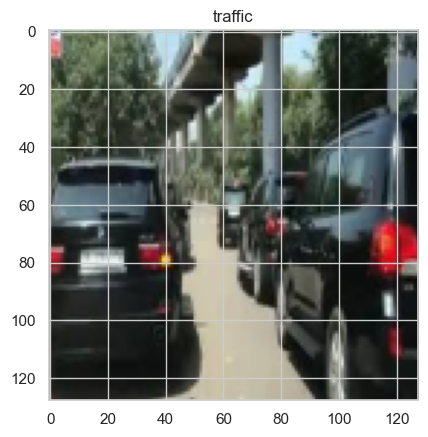

In [27]:
plt.imshow(images[86])
plt.title(class_names[86])

Text(0.5, 1.0, 'traffic')

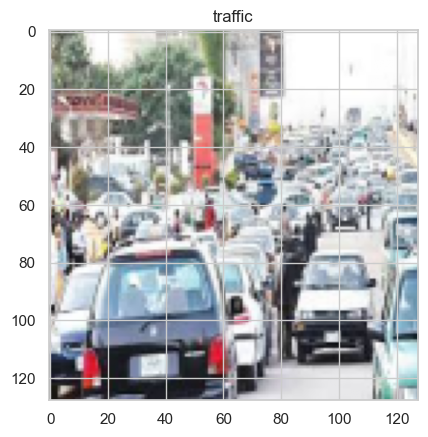

In [28]:
plt.imshow(images[365])
plt.title(class_names[365])

In [29]:
images = np.array(images)

In [30]:
images.shape

(10000, 128, 128, 3)

In [31]:
data['class_label']

47      traffic
10    ambulance
1     ambulance
44      traffic
29    ambulance
        ...    
28    ambulance
37    ambulance
18    ambulance
24    ambulance
23      traffic
Name: class_label, Length: 10000, dtype: object

In [32]:
from sklearn.preprocessing import LabelBinarizer
enc = LabelBinarizer()
y = enc.fit_transform(data['class_label'])

In [33]:
enc.classes_

array(['ambulance', 'traffic'], dtype='<U9')

In [34]:
data['class_label'][:10]

47      traffic
10    ambulance
1     ambulance
44      traffic
29    ambulance
16      traffic
36      traffic
12    ambulance
5     ambulance
8       traffic
Name: class_label, dtype: object

In [35]:
y[:10]

array([[1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1]])

In [36]:
y=np.array(y)

In [37]:
y.shape

(10000, 1)

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(images, y, test_size=0.3,stratify = y,random_state=42)

In [39]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7000, 128, 128, 3), (7000, 1), (3000, 128, 128, 3), (3000, 1))

In [40]:
batch_size = None

from keras.models import Sequential
from keras.layers import Conv2D

model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(5, 5), padding='same',
                 activation='relu', input_shape=(128, 128, 3)))



model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same',
                 activation ='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.2))


model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same',
                 activation ='relu'))
model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'same',
                 activation ='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.3))

model.add(Conv2D(filters = 128, kernel_size = (3,3),padding = 'Same',
                 activation ='relu'))
model.add(Conv2D(filters = 128, kernel_size = (3,3),padding = 'Same',
                 activation ='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(GlobalMaxPooling2D())
model.add(Dense(256, activation = "relu"))
model.add(Dense(1, activation = "softmax"))
model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      2432      
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      25632     
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 64, 64, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 64, 64, 64)        36928     
                                                      

In [41]:
#Compile the model
opt = Adam(learning_rate=0.001)
optimizer = RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [42]:
history= model.fit(X_train, y_train, epochs = 10, validation_data = (X_test,y_test),batch_size =64)

Epoch 1/10


C:\Users\asus\anaconda33\Lib\site-packages\tensorflow\python\util\dispatch.py:1260: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return dispatch_target(*args, **kwargs)




110/110 [==============================] - 433s 4s/step - loss: 0.0000e+00 - accuracy: 0.5000 - val_loss: 0.0000e+00 - val_accuracy: 0.5000
Epoch 2/10
110/110 [==============================] - 406s 4s/step - loss: 0.0000e+00 - accuracy: 0.5000 - val_loss: 0.0000e+00 - val_accuracy: 0.5000
Epoch 3/10
110/110 [==============================] - 360s 3s/step - loss: 0.0000e+00 - accuracy: 0.5000 - val_loss: 0.0000e+00 - val_accuracy: 0.5000
Epoch 4/10
110/110 [==============================] - 360s 3s/step - loss: 0.0000e+00 - accuracy: 0.5000 - val_loss: 0.0000e+00 - val_accuracy: 0.5000
Epoch 5/10
110/110 [==============================] - 349s 3s/step - loss: 0.0000e+00 - accuracy: 0.5000 - val_loss: 0.0000e+00 - val_accuracy: 0.5000
Epoch 6/10
110/110 [==============================] - 348s 3s/step - loss: 0.0000e+00 - accuracy: 0.5000 - val_loss: 0.0000e+00 - val_accuracy: 0.5000
Epoch 7/10
110/110 [==============================] - 343s 3s/step - loss: 0.0000e+00 - accuracy: 0.500

In [ ]:
# plot the accuracy plot
plt.plot(history.history['accuracy'], 'r')
plt.plot(history.history['val_accuracy'], 'b')
plt.legend({'Train Accuracy': 'r', 'Test Accuracy':'b'})
plt.show()

In [ ]:
# plot the accuracy plot
plt.plot(history.history['loss'], 'r')
plt.plot(history.history['val_loss'], 'b')
plt.legend({'Train Loss': 'r', 'Test Loss':'b'})
plt.show()

In [ ]:
#print the test accuracy
score = model.evaluate(X_test, y_test, verbose=0)
print('Test accuracy:', score[1])

In [ ]:
score_1 = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy : ", score_1[1])

In [47]:
results = pd.DataFrame(columns=['model', 'test_accuracy'])
new = ['CNN', score_1[1]]
results.loc[0] = new

In [48]:
results

,model,test_accuracy
0,CNN,0.5


In [ ]:
from keras.applications.vgg16 import VGG16

In [ ]:
vgg = VGG16(weights='imagenet',include_top=False,input_shape=(128,128,3))

In [ ]:
vgg.trainable = False

In [52]:
# Set the vgg16 model
model_1=Sequential()
model_1.add(vgg)
model_1.add(Dense(128, activation='relu'))
model_1.add(Dropout(0.2))
model_1.add(Flatten())
model_1.add(Dense(128, activation='relu'))
model_1.add(Dropout(0.2))
model_1.add(Dense(1, activation='softmax'))
model_1.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 dense_2 (Dense)             (None, 4, 4, 128)         65664     
                                                                 
 dropout_2 (Dropout)         (None, 4, 4, 128)         0         
                                                                 
 flatten (Flatten)           (None, 2048)              0         
                                                                 
 dense_3 (Dense)             (None, 128)               262272    
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_4 (Dense)             (None, 1)                

In [ ]:
opt = Adam(learning_rate=0.001)
optimizer = RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08)
model_1.compile(optimizer = opt, loss = "binary_crossentropy", metrics = ["accuracy"])

In [ ]:
his2= model_1.fit(X_train, y_train, epochs = 3, validation_data = (X_test,y_test),batch_size =24)

In [ ]:
score_1 = model_1.evaluate(X_test, y_test, verbose=0)
print('Test accuracy:', score_1[1])

In [ ]:
new = ['VGG16', score_1[1]]
results.loc[1] = new